In [1]:

import sys
import os
sys.path.append('../TCT/')
from TCT import node_normalizer
from TCT import name_resolver
from TCT import translator_metakg
from TCT import translator_kpinfo
from TCT import translator_query
from TCT import TCT_neighborhood_finder

from TCT import TCT

In [2]:
APInames, metaKG, Translator_KP_info= translator_metakg.load_translator_resources(use_new_metakg_url=True)

All_predicates = list(set(metaKG['Predicate']))
All_categories = list((set(list(set(metaKG['Subject']))+list(set(metaKG['Object'])))))
API_withMetaKG = list(set(metaKG['API']))

    # generate a dictionary of API and its predicates
API_predicates = {}
for api in API_withMetaKG:
    API_predicates[api] = list(set(metaKG[metaKG['API'] == api]['Predicate']))

Skipping server without x-maturity: {'description': 'Local dev', 'url': 'http://127.0.0.1:5001'}
Skipping server without x-maturity: {'description': 'Local dev', 'url': 'http://127.0.0.1:5001'}
Skipping server without x-maturity: {'url': '/sipr'}


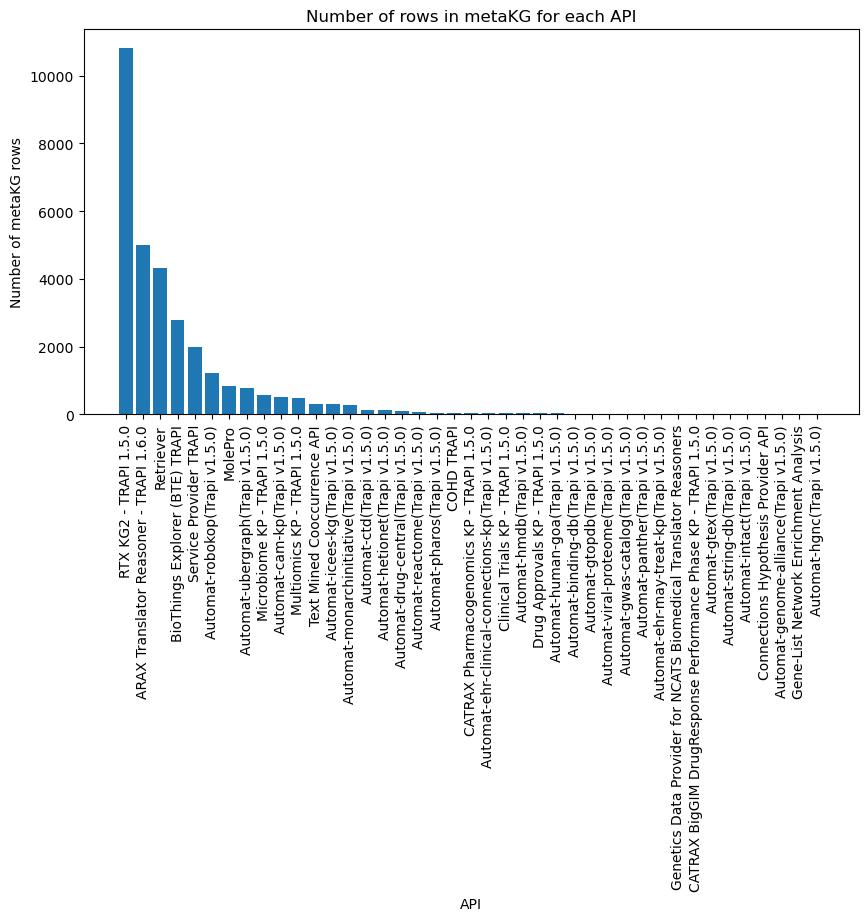

In [3]:

import numpy as np
# calulate how many rows each API has in the metaKG
API_row_count = {}
for api in API_withMetaKG:
    API_row_count[api] = len(metaKG[metaKG['API'] == api])
# sort the API by the number of rows in the metaKG
API_row_count = dict(sorted(API_row_count.items(), key=lambda item: item[1], reverse=True))
API_row_count

# draw a bar chart of the API and the number of rows in the metaKG
import matplotlib.pyplot as plt 
plt.figure(figsize=(10,5))

plt.bar(API_row_count.keys(), API_row_count.values())
plt.xticks(rotation=90)
plt.xlabel('API')
plt.ylabel('Number of metaKG rows')
plt.title('Number of rows in metaKG for each API')
plt.show()